#**UCI Adult Income Dataset — Data Ingestion, Wrangling, Cleaning & Preprocessing**

#Task 1 — Data Ingestion

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('adult.data')

In [ ]:
df.shape

(32560, 15)

In [ ]:
df.head()

,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
0,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
1,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
2,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
3,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
4,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K


In [ ]:
df.columns = ['Age','Job Type','Code','Education','Education Years','Marital status','Occupation','Relationship','Ethnicity','Gender','Capital Gain','Capital Loss','Work hours per week','Country','Income']

In [ ]:
df.columns

Index(['Age', 'Job Type', 'Code', 'Education', 'Education Years',
       'Marital status', 'Occupation', 'Relationship', 'Ethnicity', 'Gender',
       'Capital Gain', 'Capital Loss', 'Work hours per week', 'Country',
       'Income'],
      dtype='object')

In [ ]:
df.dtypes

,0
Age,int64
Job Type,object
Code,int64
Education,object
Education Years,int64
Marital status,object
Occupation,object
Relationship,object
Ethnicity,object
Gender,object


#Task 2 — Find the Problems Before Cleaning

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32560 entries, 0 to 32559
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Age                  32560 non-null  int64 
 1   Job Type             32560 non-null  object
 2   Code                 32560 non-null  int64 
 3   Education            32560 non-null  object
 4   Education Years      32560 non-null  int64 
 5   Marital status       32560 non-null  object
 6   Occupation           32560 non-null  object
 7   Relationship         32560 non-null  object
 8   Ethnicity            32560 non-null  object
 9   Gender               32560 non-null  object
 10  Capital Gain         32560 non-null  int64 
 11  Capital Loss         32560 non-null  int64 
 12  Work hours per week  32560 non-null  int64 
 13  Country              32560 non-null  object
 14  Income               32560 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [ ]:
df.describe()

,Age,Code,Education Years,Capital Gain,Capital Loss,Work hours per week
count,32560.000000,3.256000e+04,32560.000000,32560.000000,32560.000000,32560.000000
mean,38.581634,1.897818e+05,10.080590,1077.615172,87.306511,40.437469
std,13.640642,1.055498e+05,2.572709,7385.402999,402.966116,12.347618
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178315e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783630e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370545e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [ ]:
column_names = df.columns.values.tolist()
for col in column_names:
  print(col+': ')
  print(df[col].unique())

Age: 
[50 38 53 28 37 49 52 31 42 30 23 32 40 34 25 43 54 35 59 56 19 39 20 45
 22 48 21 24 57 44 41 29 18 47 46 36 79 27 67 33 76 17 55 61 70 64 71 68
 66 51 58 26 60 90 75 65 77 62 63 80 72 74 69 73 81 78 88 82 83 84 85 86
 87]
Job Type: 
[' Self-emp-not-inc' ' Private' ' State-gov' ' Federal-gov' ' Local-gov'
 ' ?' ' Self-emp-inc' ' Without-pay' ' Never-worked']
Code: 
[ 83311 215646 234721 ...  34066  84661 257302]
Education: 
[' Bachelors' ' HS-grad' ' 11th' ' Masters' ' 9th' ' Some-college'
 ' Assoc-acdm' ' Assoc-voc' ' 7th-8th' ' Doctorate' ' Prof-school'
 ' 5th-6th' ' 10th' ' 1st-4th' ' Preschool' ' 12th']
Education Years: 
[13  9  7 14  5 10 12 11  4 16 15  3  6  2  1  8]
Marital status: 
[' Married-civ-spouse' ' Divorced' ' Married-spouse-absent'
 ' Never-married' ' Separated' ' Married-AF-spouse' ' Widowed']
Occupation: 
[' Exec-managerial' ' Handlers-cleaners' ' Prof-specialty'
 ' Other-service' ' Adm-clerical' ' Sales' ' Craft-repair'
 ' Transport-moving' ' Farming-fishing

In [ ]:
for col in [column_names]:
  print(df[col].value_counts())

Age  Job Type          Code    Education     Education Years  Marital status      Occupation       Relationship   Ethnicity  Gender  Capital Gain  Capital Loss  Work hours per week  Country        Income
25   Private           195994  1st-4th       2                Never-married       Priv-house-serv  Not-in-family  White      Female  0             0             40                   Guatemala      <=50K     3
30   Private           144593  HS-grad       9                Never-married       Other-service    Not-in-family  Black      Male    0             0             40                   ?              <=50K     2
49   Self-emp-not-inc  43479   Some-college  10               Married-civ-spouse  Craft-repair     Husband        White      Male    0             0             40                   United-States  <=50K     2
19   Private           251579  Some-college  10               Never-married       Other-service    Own-child      White      Male    0             0             14      

In [ ]:
df['Job Type'].isin([' ?']).value_counts()

,count
Job Type,
False,30724
True,1836


In [ ]:
df['Occupation'].isin([' ?']).value_counts()

,count
Occupation,
False,30717
True,1843


In [ ]:
df['Country'].isin([' ?']).value_counts()

,count
Country,
False,31977
True,583


In [ ]:
total_duplicates = df.duplicated().sum()
print(total_duplicates)

24


In [ ]:
num_cols =  ['Age', 'Code', 'Education Years', 'Capital Gain', 'Capital Loss', 'Work hours per week']
df[num_cols].describe()

,Age,Code,Education Years,Capital Gain,Capital Loss,Work hours per week
count,32560.000000,3.256000e+04,32560.000000,32560.000000,32560.000000,32560.000000
mean,38.581634,1.897818e+05,10.080590,1077.615172,87.306511,40.437469
std,13.640642,1.055498e+05,2.572709,7385.402999,402.966116,12.347618
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178315e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783630e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370545e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


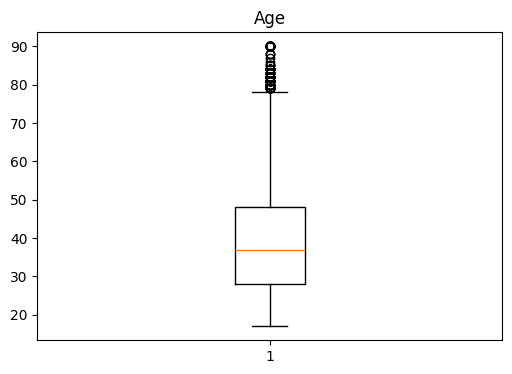

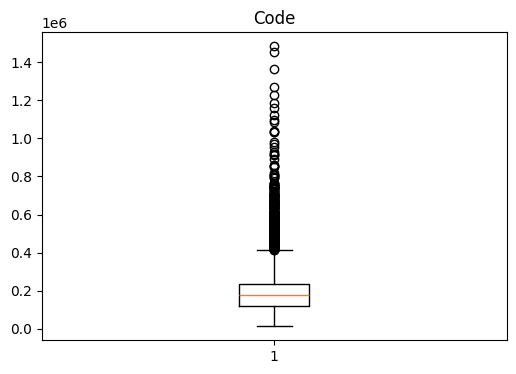

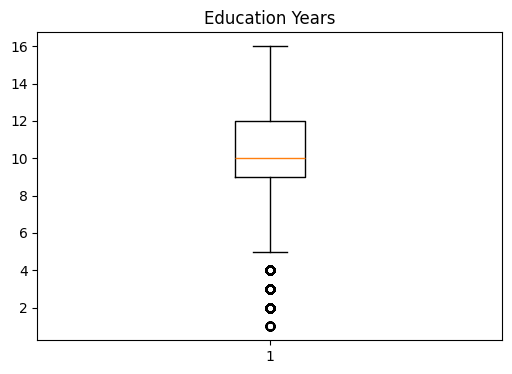

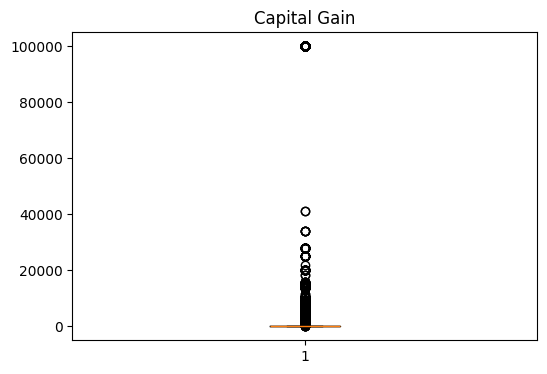

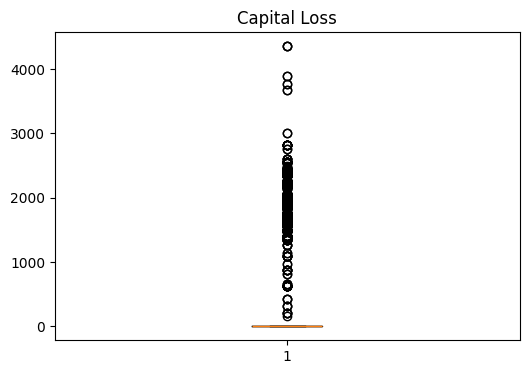

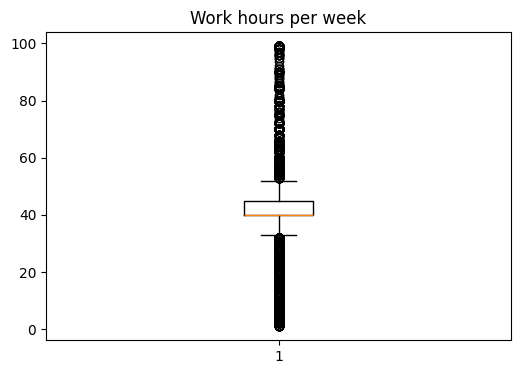

In [ ]:
import matplotlib.pyplot as plt
for col in num_cols:
  plt.figure(figsize=(6,4))
  plt.boxplot(df[col])
  plt.title(col)
  plt.show

In [ ]:
df.columns

Index(['Age', 'Job Type', 'Code', 'Education', 'Education Years',
       'Marital status', 'Occupation', 'Relationship', 'Ethnicity', 'Gender',
       'Capital Gain', 'Capital Loss', 'Work hours per week', 'Country',
       'Income'],
      dtype='object')

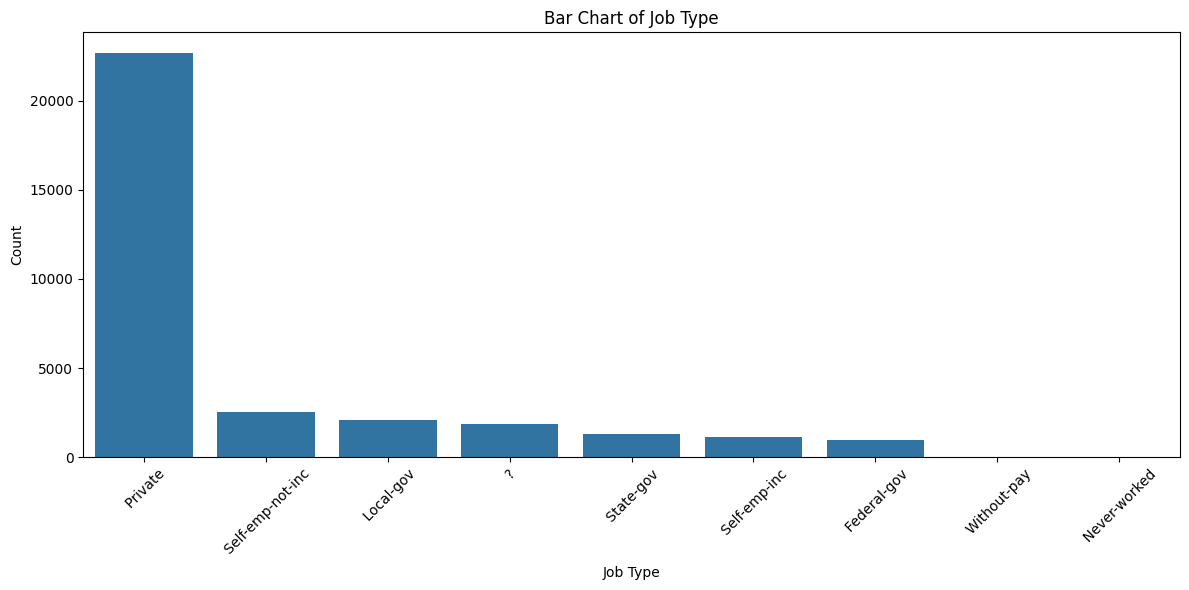

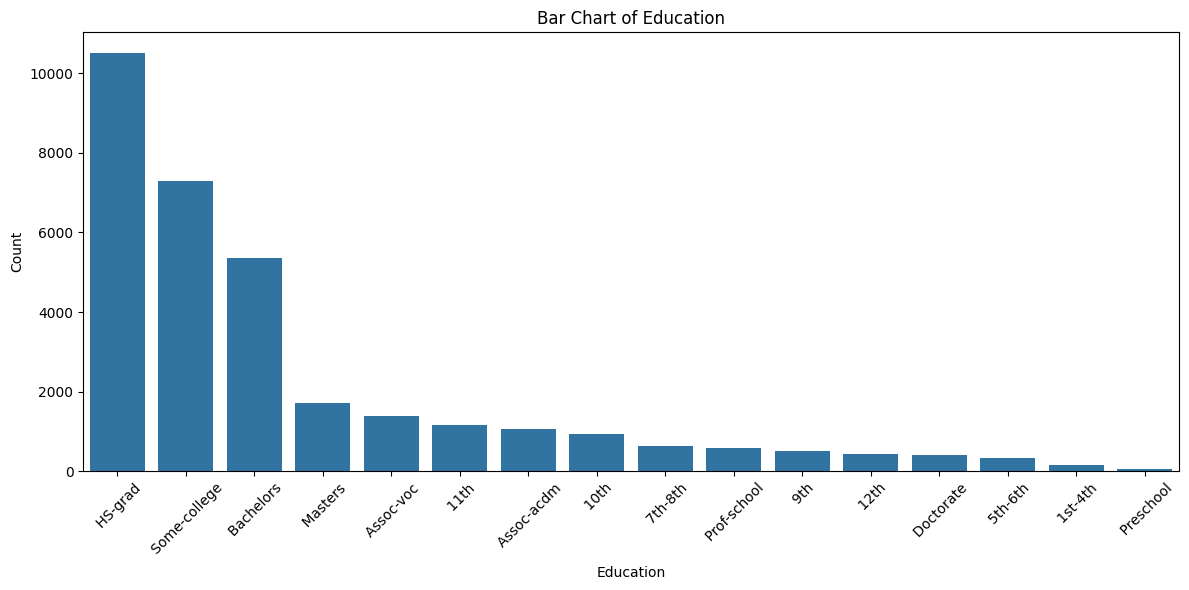

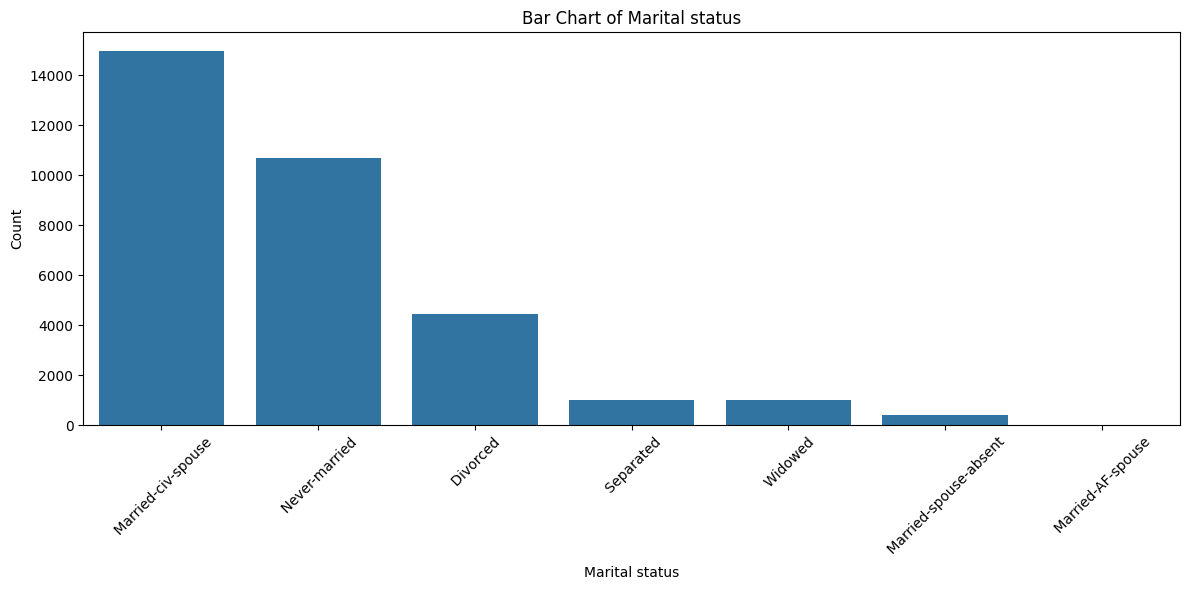

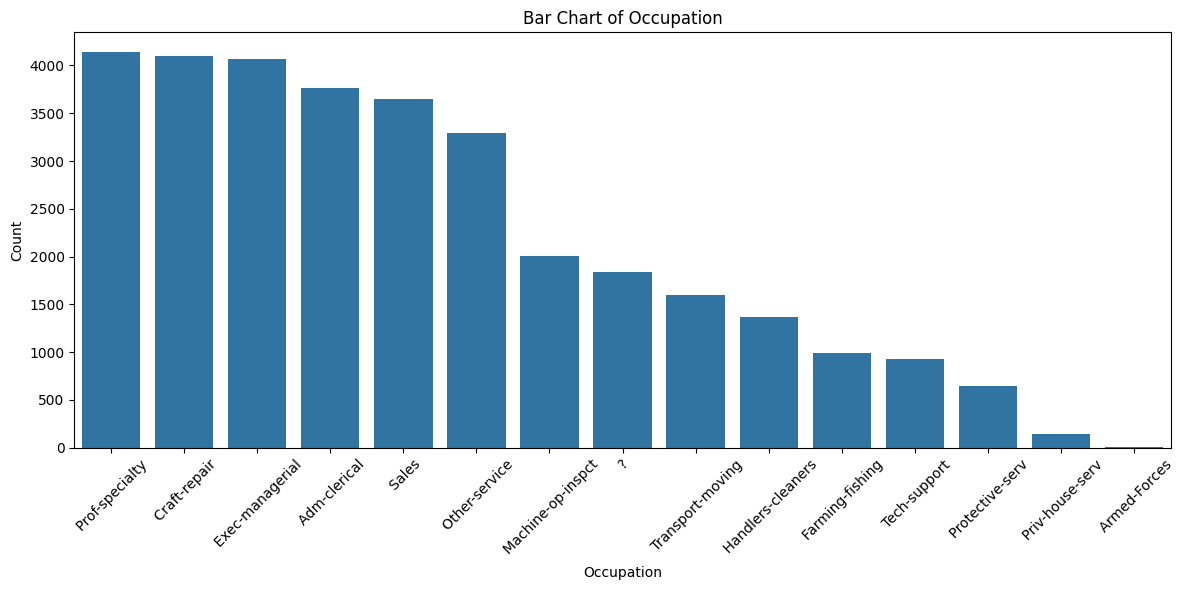

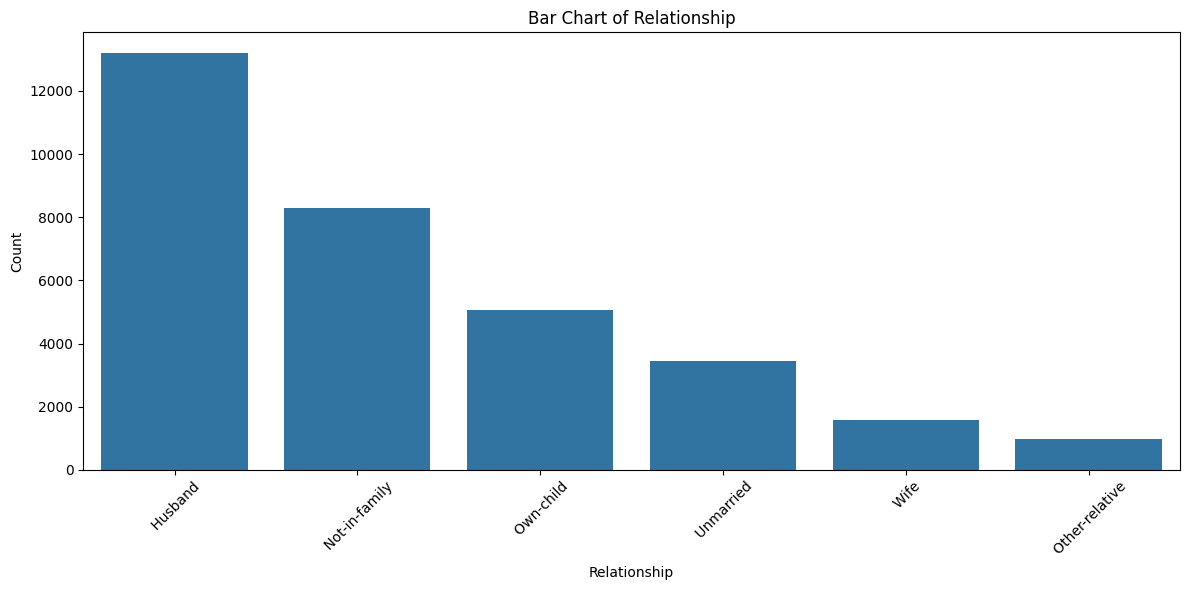

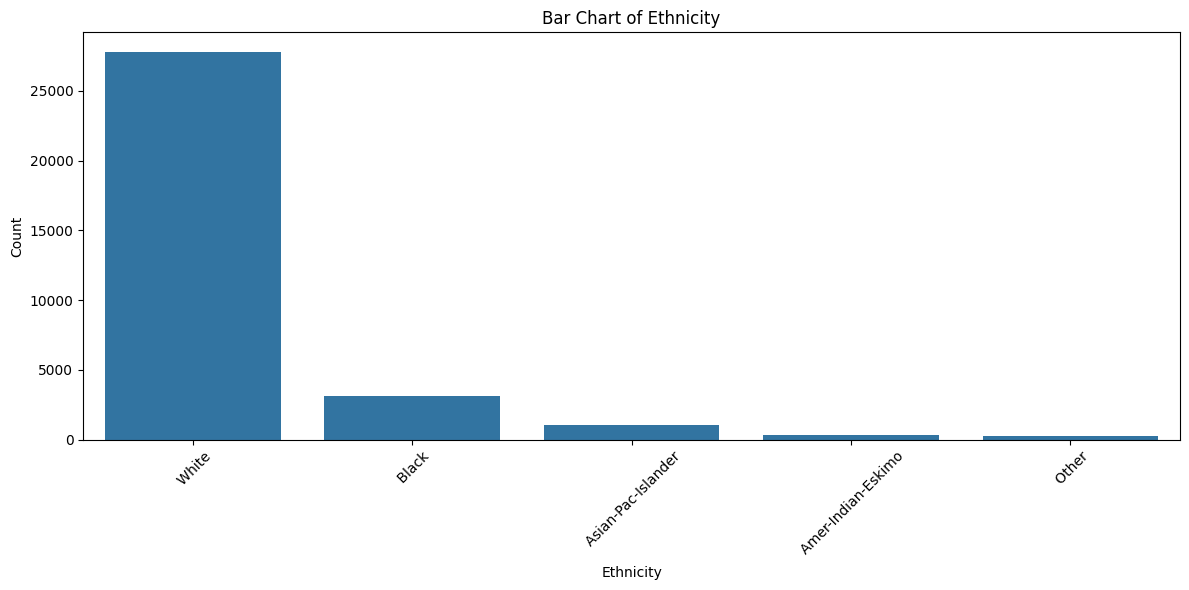

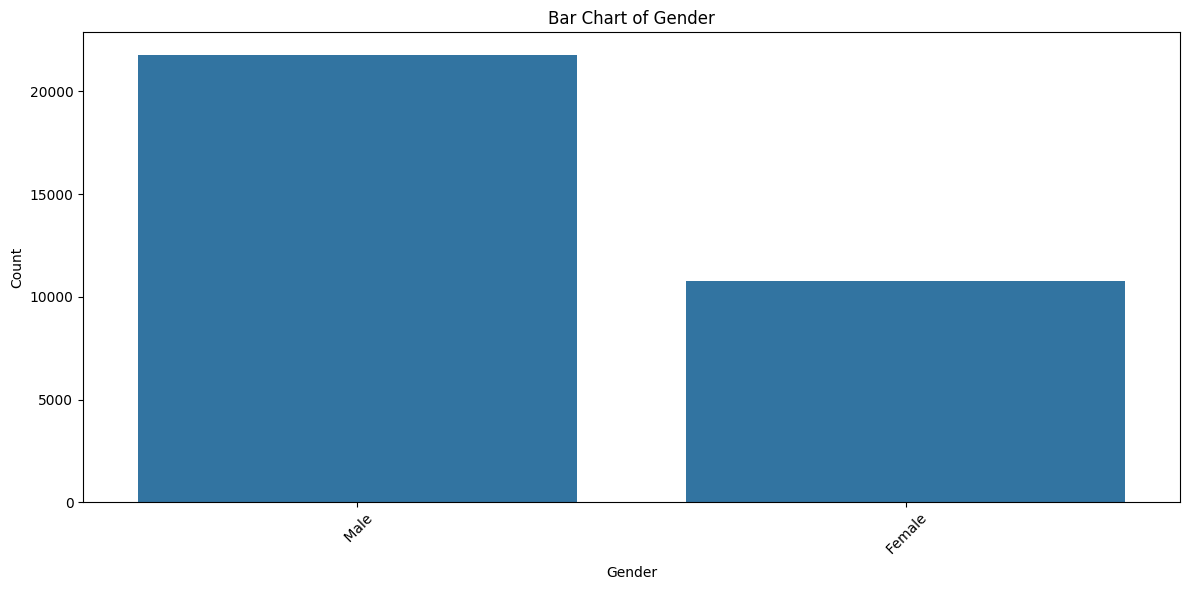

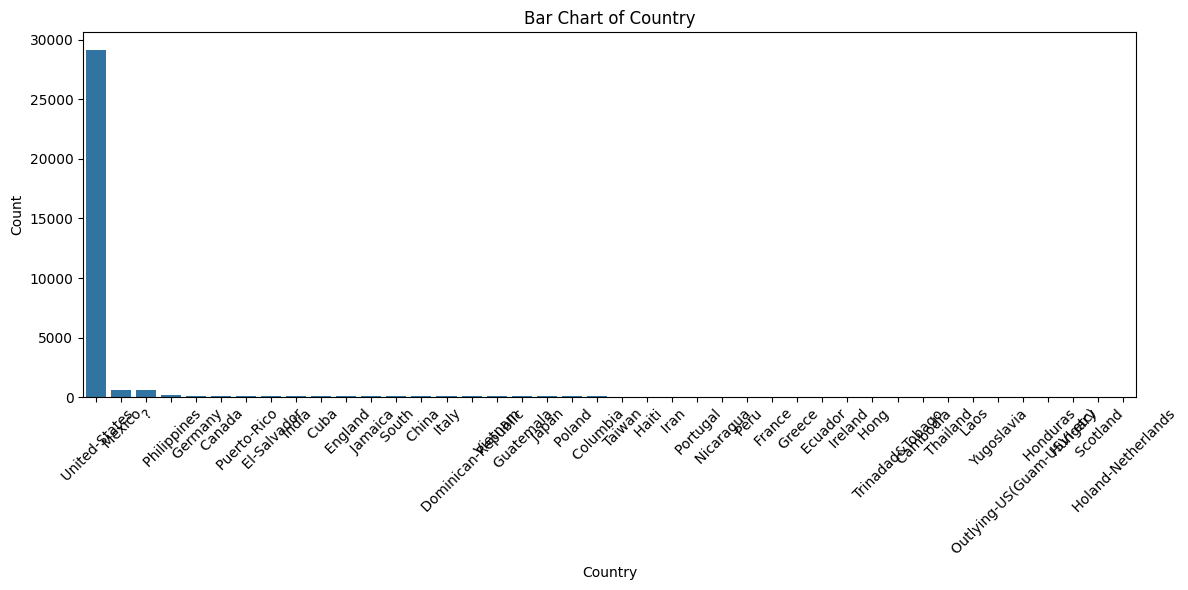

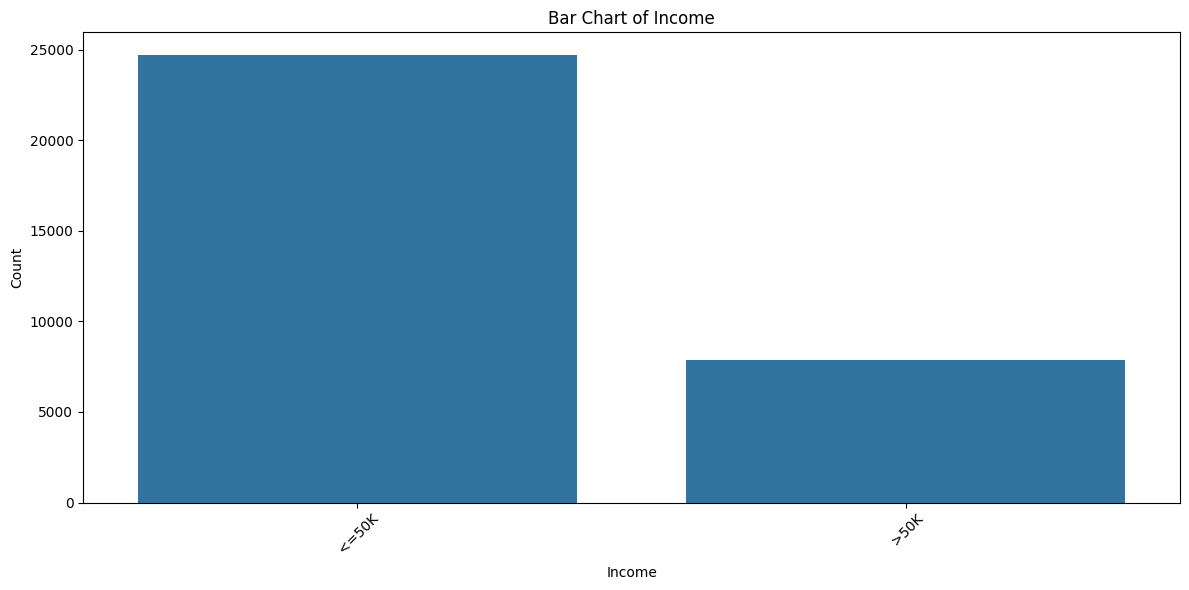

In [ ]:
import seaborn as sns

cat_cols = ['Job Type', 'Education', 'Marital status', 'Occupation', 'Relationship', 'Ethnicity', 'Gender', 'Country', 'Income']
for col in cat_cols:
  plt.figure(figsize=(12,6))
  sns.countplot(data=df, x=col, order=df[col].value_counts().index)
  plt.title(f'Bar Chart of {col}')
  plt.xlabel(col)
  plt.ylabel("Count")
  plt.xticks(rotation=45)
  plt.tight_layout()
  plt.show()

#Task 3 — Missing-Value Investigation

In [ ]:
import numpy as np

df_clean = df.replace(' ?',np.nan)

In [ ]:
df_clean.isin([' ?']).sum()

,0
Age,0
Job Type,0
Code,0
Education,0
Education Years,0
Marital status,0
Occupation,0
Relationship,0
Ethnicity,0
Gender,0


In [ ]:
df_clean.isna().sum()

,0
Age,0
Job Type,1836
Code,0
Education,0
Education Years,0
Marital status,0
Occupation,1843
Relationship,0
Ethnicity,0
Gender,0


In [ ]:
df_clean.isna().any(axis=1).sum()

np.int64(2399)

In [ ]:
df_clean.isna().any(axis=1).mean()*100

np.float64(7.367936117936118)

In [ ]:
print(df_clean[100:150])

     Age           Job Type    Code      Education  Education Years  \
100   44            Private  198282      Bachelors               13   
101   47   Self-emp-not-inc  149116        Masters               14   
102   20            Private  188300   Some-college               10   
103   29            Private  103432        HS-grad                9   
104   32       Self-emp-inc  317660        HS-grad                9   
105   17                NaN  304873           10th                6   
106   30            Private  194901           11th                7   
107   31          Local-gov  189265        HS-grad                9   
108   42            Private  124692        HS-grad                9   
109   24            Private  432376      Bachelors               13   
110   38            Private   65324    Prof-school               15   
111   56   Self-emp-not-inc  335605        HS-grad                9   
112   28            Private  377869   Some-college               10   
113   

In [ ]:
for col in df_clean.columns:
  df_clean[col]= df_clean[col].fillna('Unknown')

In [ ]:
df_clean.isna().sum()

,0
Age,0
Job Type,0
Code,0
Education,0
Education Years,0
Marital status,0
Occupation,0
Relationship,0
Ethnicity,0
Gender,0


#Task 4 — Target Distribution

In [ ]:
df_clean['Income'].value_counts(normalize=True)*100

,proportion
Income,
<=50K,75.918305
>50K,24.081695


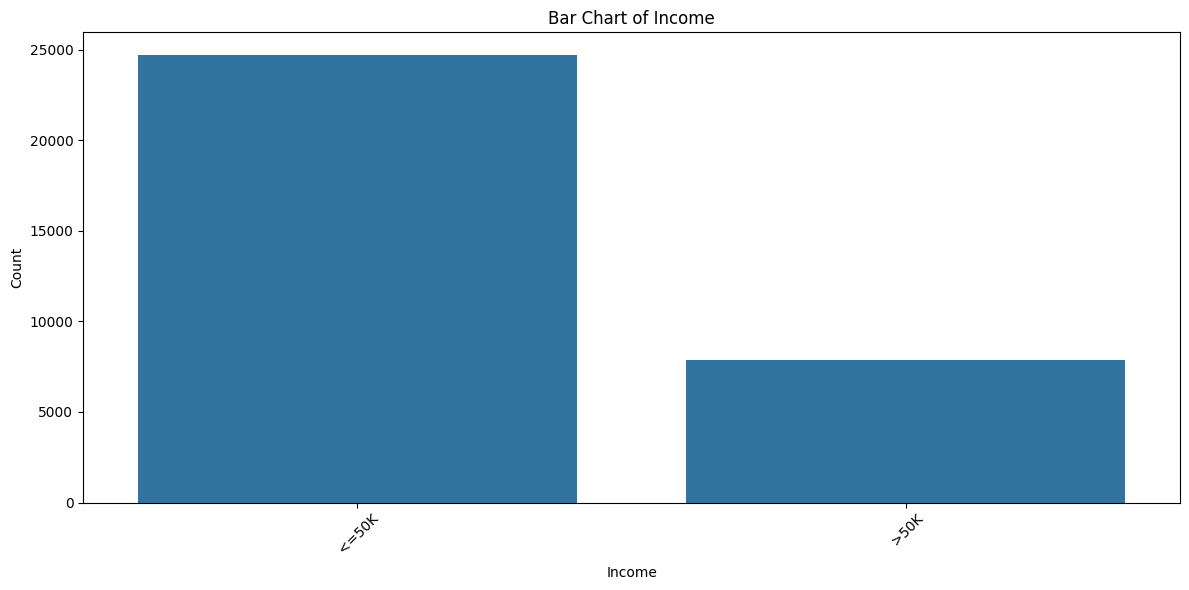

In [ ]:
plt.figure(figsize=(12,6))
sns.countplot(data=df_clean, x='Income', order=df_clean['Income'].value_counts().index)
plt.title(f'Bar Chart of {'Income'}')
plt.xlabel('Income')
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#Task 5 — Categorical Data Consistency

In [ ]:
for col in cat_cols:
  print(df_clean[col].value_counts())

Job Type
 Private             22696
 Self-emp-not-inc     2541
 Local-gov            2093
Unknown               1836
 State-gov            1297
 Self-emp-inc         1116
 Federal-gov           960
 Without-pay            14
 Never-worked            7
Name: count, dtype: int64
Education
HS-grad         10501
Some-college     7291
Bachelors        5354
Masters          1723
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           646
Prof-school       576
9th               514
12th              433
Doctorate         413
5th-6th           333
1st-4th           168
Preschool          51
Name: count, dtype: int64
Marital status
Married-civ-spouse       14976
Never-married            10682
Divorced                  4443
Separated                 1025
Widowed                    993
Married-spouse-absent      418
Married-AF-spouse           23
Name: count, dtype: int64
Occupation
 Prof-specialty       4140
 Craft-repair         4099
 Exec-manag

In [ ]:
df_clean[cat_cols] = df_clean[cat_cols].apply(lambda x: x.str.strip())

In [ ]:
for col in cat_cols:
  print(df_clean[col].value_counts())

Job Type
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
Unknown              1836
State-gov            1297
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64
Education
HS-grad         10501
Some-college     7291
Bachelors        5354
Masters          1723
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           646
Prof-school       576
9th               514
12th              433
Doctorate         413
5th-6th           333
1st-4th           168
Preschool          51
Name: count, dtype: int64
Marital status
Married-civ-spouse       14976
Never-married            10682
Divorced                  4443
Separated                 1025
Widowed                    993
Married-spouse-absent      418
Married-AF-spouse           23
Name: count, dtype: int64
Occupation
Prof-specialty       4140
Craft-repair         4099
Exec-managerial      4

#Task 6 — Duplicate Records

In [ ]:
df_clean.duplicated().sum()

np.int64(24)

In [ ]:
duplicates = df_clean[df_clean.duplicated(keep=False)]
print("Total duplicate records:", len(duplicates))

Total duplicate records: 47


In [ ]:
duplicates

,Age,Job Type,Code,Education,Education Years,Marital status,Occupation,Relationship,Ethnicity,Gender,Capital Gain,Capital Loss,Work hours per week,Country,Income
2302,90,Private,52386,Some-college,10,Never-married,Other-service,Not-in-family,Asian-Pac-Islander,Male,0,0,35,United-States,<=50K
3916,19,Private,251579,Some-college,10,Never-married,Other-service,Own-child,White,Male,0,0,14,United-States,<=50K
4324,25,Private,308144,Bachelors,13,Never-married,Craft-repair,Not-in-family,White,Male,0,0,40,Mexico,<=50K
4766,21,Private,250051,Some-college,10,Never-married,Prof-specialty,Own-child,White,Female,0,0,10,United-States,<=50K
4880,25,Private,308144,Bachelors,13,Never-married,Craft-repair,Not-in-family,White,Male,0,0,40,Mexico,<=50K
4939,38,Private,207202,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,48,United-States,>50K
5103,90,Private,52386,Some-college,10,Never-married,Other-service,Not-in-family,Asian-Pac-Islander,Male,0,0,35,United-States,<=50K
5578,27,Private,255582,HS-grad,9,Never-married,Machine-op-inspct,Not-in-family,White,Female,0,0,40,United-States,<=50K
5804,20,Private,107658,Some-college,10,Never-married,Tech-support,Not-in-family,White,Female,0,0,10,United-States,<=50K
5841,25,Private,195994,1st-4th,2,Never-married,Priv-house-serv,Not-in-family,White,Female,0,0,40,Guatemala,<=50K


In [ ]:
df_clean = df_clean.drop_duplicates()

In [ ]:
df_clean.duplicated().sum()

np.int64(0)

#Task 7 — Outlier Investigation

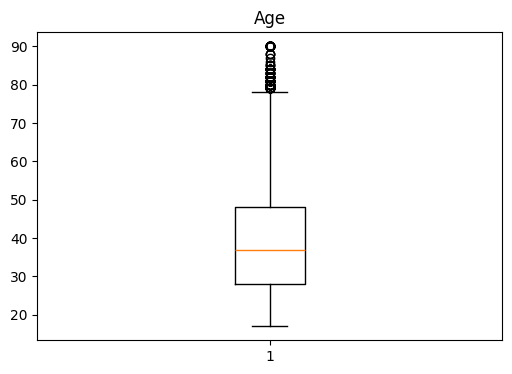

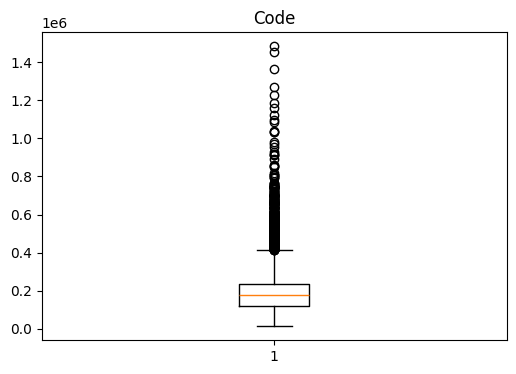

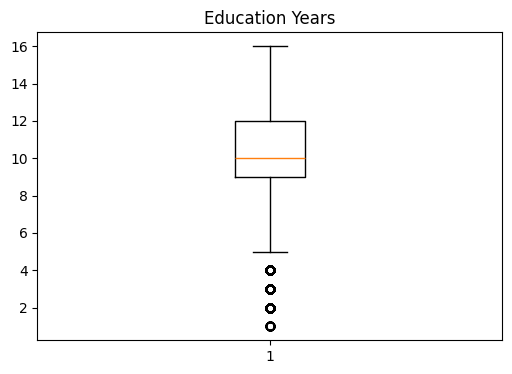

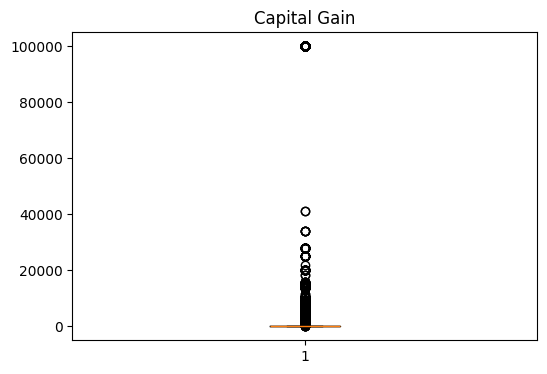

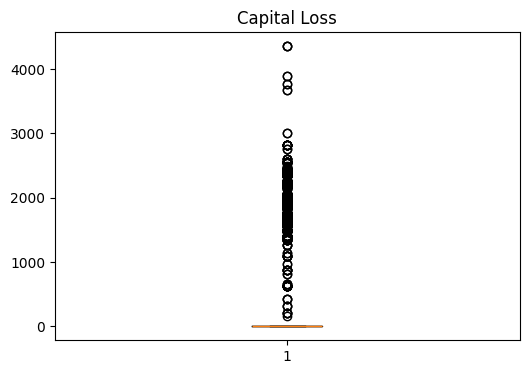

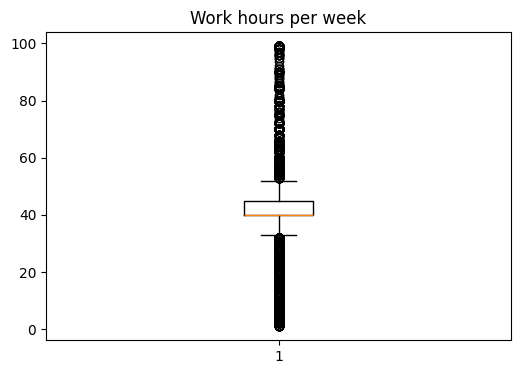

In [ ]:
for col in num_cols:
  plt.figure(figsize=(6,4))
  plt.boxplot(df_clean[col])
  plt.title(col)
  plt.show

In [ ]:
df_clean = df_clean[df_clean['Capital Gain'] < 99999]

In [ ]:
df_clean.describe()

,Age,Code,Education Years,Capital Gain,Capital Loss,Work hours per week
count,32377.000000,3.237700e+04,32377.000000,32377.000000,32377.000000,32377.000000
mean,38.547364,1.897687e+05,10.067795,592.621583,87.799981,40.394385
std,13.639497,1.055766e+05,2.564381,2561.181831,404.049748,12.329245
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.177980e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783830e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.369930e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,41310.000000,4356.000000,99.000000


#Task 9 — Build a Professional Preprocessing Pipeline

In [ ]:
df_clean['Income'] = df_clean['Income'].map({
    '<=50K' : 0,
    '>50K': 1
})

In [ ]:
df_clean['Income'].value_counts()

,count
Income,
0,24697
1,7680


In [ ]:
x = df_clean.drop('Income',axis=1)
y = df_clean['Income']

In [ ]:
x.shape

(32377, 14)

In [ ]:
y.shape

(32377,)

In [ ]:
x.head()

,Age,Job Type,Code,Education,Education Years,Marital status,Occupation,Relationship,Ethnicity,Gender,Capital Gain,Capital Loss,Work hours per week,Country
0,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States
1,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States
2,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States
3,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba
4,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States


In [ ]:
y.head()

,Income
0,0
1,0
2,0
3,0
4,0


In [ ]:
num_cols = x.select_dtypes(include=['int64', 'float64']).columns.tolist()

cat_cols = x.select_dtypes(include=['object']).columns.tolist()

In [ ]:
print("Numerical Features:")
print(num_cols)

print("\nCategorical Features:")
print(cat_cols)

Numerical Features:
['Age', 'Code', 'Education Years', 'Capital Gain', 'Capital Loss', 'Work hours per week']

Categorical Features:
['Job Type', 'Education', 'Marital status', 'Occupation', 'Relationship', 'Ethnicity', 'Gender', 'Country']


In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

numeric_pipeline = Pipeline([
    ('imputer',SimpleImputer(strategy = 'median')),
    ('scaler', StandardScaler())
])

In [ ]:
from sklearn.preprocessing import OneHotEncoder

categorical_pipeline = Pipeline([
    ('imputer',SimpleImputer(strategy='constant' , fill_value='Unknown')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

In [ ]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, num_cols),
    ('cat', categorical_pipeline, cat_cols)
])

#**EDA Phase — Understanding Income Patterns in Adult Dataset**

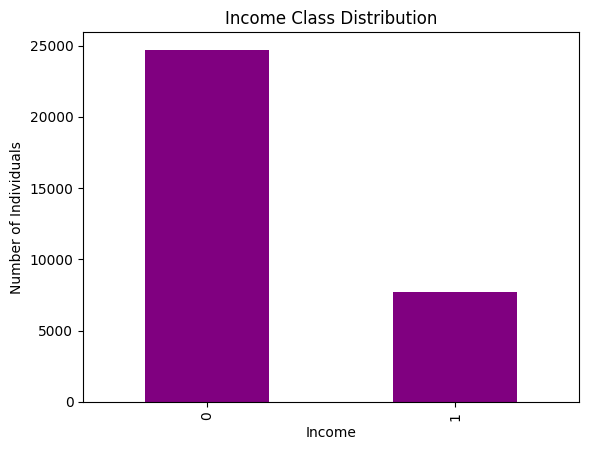

In [ ]:
import matplotlib.pyplot as plt

df_clean['Income'].value_counts().plot(
    kind='bar',
    color='purple'
)

plt.title('Income Class Distribution')
plt.xlabel('Income')
plt.ylabel('Number of Individuals')
plt.show()

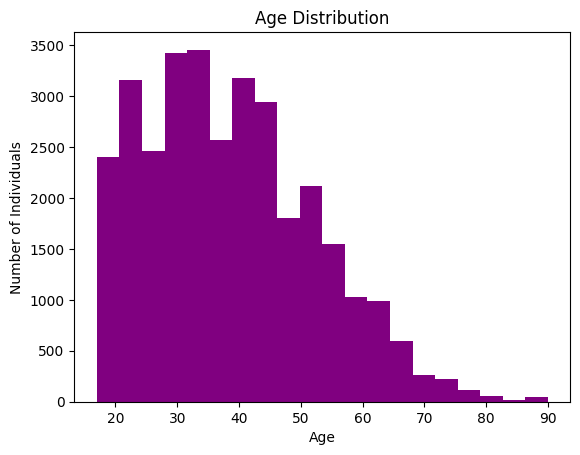

In [ ]:
plt.hist(df_clean['Age'], bins=20, color='purple')

plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Individuals')

plt.show()

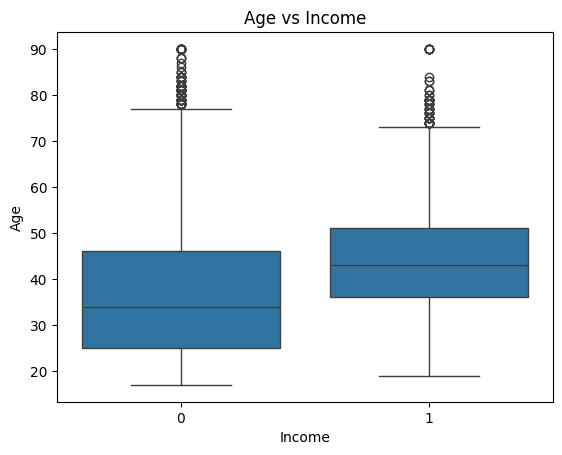

In [ ]:
sns.boxplot(data=df_clean, x='Income', y='Age')

plt.title('Age vs Income')
plt.xlabel('Income')
plt.ylabel('Age')

plt.show()

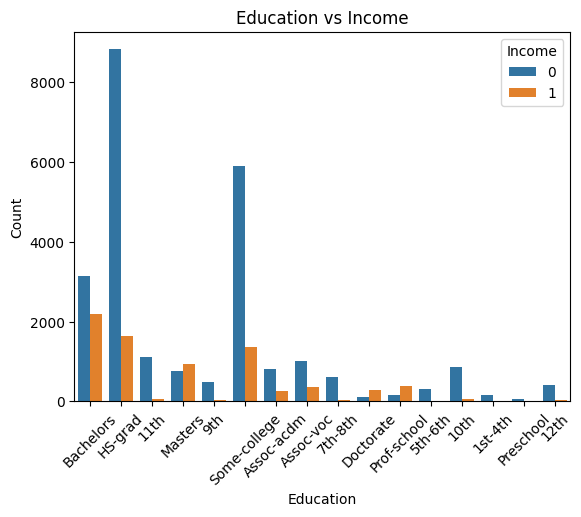

In [ ]:
sns.countplot(data=df_clean, x='Education', hue='Income')

plt.title('Education vs Income')
plt.xlabel('Education')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.show()

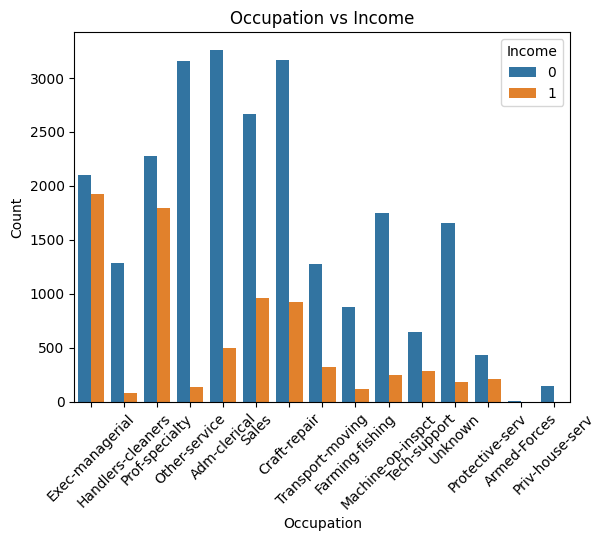

In [ ]:
sns.countplot(data=df_clean, x='Occupation', hue='Income')

plt.title('Occupation vs Income')
plt.xlabel('Occupation')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.show()

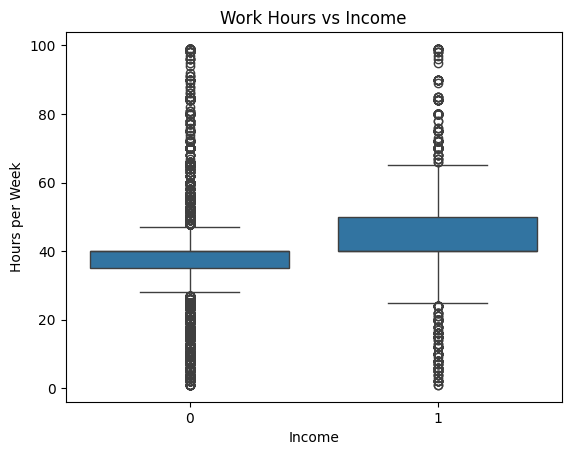

In [ ]:
sns.boxplot(data=df_clean, x='Income', y='Work hours per week')

plt.title('Work Hours vs Income')
plt.xlabel('Income')
plt.ylabel('Hours per Week')

plt.show()

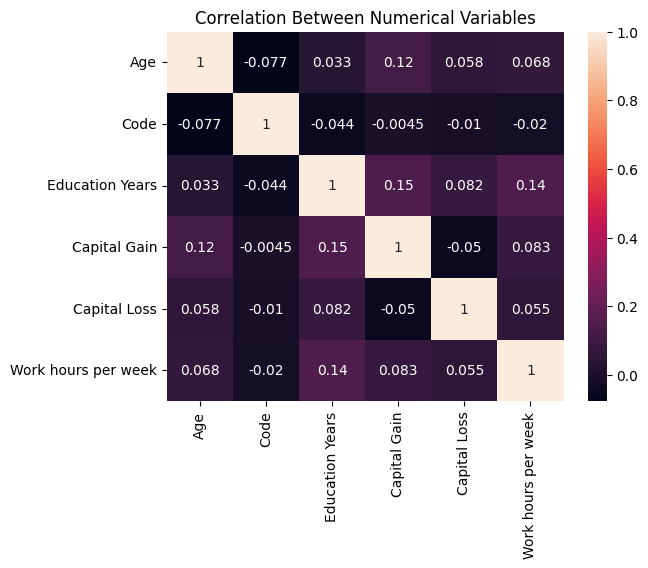

In [ ]:
corr = df_clean[num_cols].corr()

sns.heatmap(corr, annot=True)

plt.title('Correlation Between Numerical Variables')

plt.show()